## Introduction to Pandas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


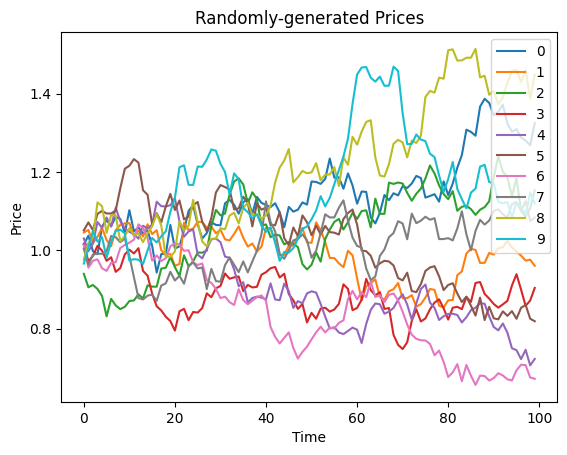

In [2]:
returns = pd.DataFrame(np.random.normal(1.0, 0.03, (100, 10)))
prices = returns.cumprod()
prices.plot()
plt.title('Randomly-generated Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend(loc=0);


#### Series

In [3]:
s = pd.Series([1, 2, np.nan, 4, 5])
print(s)


0    1.0
1    2.0
2    NaN
3    4.0
4    5.0
dtype: float64


In [4]:
print(s.name)


None


In [5]:
s.name = "Toy Series"
print(s.name)


Toy Series


In [6]:
print(s.index)


RangeIndex(start=0, stop=5, step=1)


In [7]:
new_index = pd.date_range("2016-01-01", periods=len(s), freq="D")
print(new_index)


DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05'],
              dtype='datetime64[us]', freq='D')


In [8]:
s.index = new_index
print(s.index)


DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05'],
              dtype='datetime64[us]', freq='D')


In [9]:
print("First element of the series:", s.iloc[0])
print("Last element of the series:", s.iloc[len(s) - 1])


First element of the series: 1.0
Last element of the series: 5.0


In [10]:
s.iloc[:2]


2016-01-01    1.0
2016-01-02    2.0
Freq: D, Name: Toy Series, dtype: float64

In [11]:
start = 0
end = len(s) - 1
step = 1

s.iloc[start:end:step]


2016-01-01    1.0
2016-01-02    2.0
2016-01-03    NaN
2016-01-04    4.0
Freq: D, Name: Toy Series, dtype: float64

In [12]:
s.iloc[::-1]


2016-01-05    5.0
2016-01-04    4.0
2016-01-03    NaN
2016-01-02    2.0
2016-01-01    1.0
Freq: -1D, Name: Toy Series, dtype: float64

In [13]:
s.iloc[-2:-4:-1]


2016-01-04    4.0
2016-01-03    NaN
Freq: -1D, Name: Toy Series, dtype: float64

In [14]:
s.loc['2016-01-1']


np.float64(1.0)

In [15]:
s.loc['2016-01-02':'2016-01-04']


2016-01-02    2.0
2016-01-03    NaN
2016-01-04    4.0
Freq: D, Name: Toy Series, dtype: float64

In [16]:
print(s < 3)


2016-01-01     True
2016-01-02     True
2016-01-03    False
2016-01-04    False
2016-01-05    False
Freq: D, Name: Toy Series, dtype: bool


In [17]:
print(s.loc[s < 3])


2016-01-01    1.0
2016-01-02    2.0
Freq: D, Name: Toy Series, dtype: float64


In [18]:
print(s.loc[(s < 3) & (s > 1)])


2016-01-02    2.0
Freq: D, Name: Toy Series, dtype: float64


In [19]:
symbol = "CMG"
start = "2012-01-01"
end = "2016-01-01"
prices = yf.download(symbol, start=start, end=end)["Close"]


[*********************100%***********************]  1 of 1 completed


In [20]:
print("\n", type(prices))
prices.head(5)



 <class 'pandas.DataFrame'>


Ticker,CMG
Date,
2012-01-03,6.8254
2012-01-04,6.9750
2012-01-05,7.0096
2012-01-06,6.9790
2012-01-09,6.7948


In [21]:
# Force prices to be a 1D Series dynamically by taking the first column
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

print("Old name:", prices.name)
prices.name = symbol
print("New name:", prices.name)


Old name: CMG
New name: CMG


In [22]:
print(prices.index)


DatetimeIndex(['2012-01-03', '2012-01-04', '2012-01-05', '2012-01-06',
               '2012-01-09', '2012-01-10', '2012-01-11', '2012-01-12',
               '2012-01-13', '2012-01-17',
               ...
               '2015-12-17', '2015-12-18', '2015-12-21', '2015-12-22',
               '2015-12-23', '2015-12-24', '2015-12-28', '2015-12-29',
               '2015-12-30', '2015-12-31'],
              dtype='datetime64[s]', name='Date', length=1006, freq=None)


In [23]:
monthly_prices = prices.resample('ME').last()
monthly_prices.head(10)


Date
2012-01-31    7.3458
2012-02-29    7.8044
2012-03-31    8.3600
2012-04-30    8.2830
2012-05-31    8.2614
2012-06-30    7.5990
2012-07-31    5.8466
2012-08-31    5.7728
2012-09-30    6.3508
2012-10-31    5.0906
Freq: ME, Name: CMG, dtype: float64

In [24]:
monthly_prices_med = prices.resample("ME").median()
monthly_prices_med.head(10)


Date
2012-01-31    7.1101
2012-02-29    7.5639
2012-03-31    8.1799
2012-04-30    8.4167
2012-05-31    8.1048
2012-06-30    8.0490
2012-07-31    7.6094
2012-08-31    5.9078
2012-09-30    6.6562
2012-10-31    5.7312
Freq: ME, Name: CMG, dtype: float64

In [25]:
def custom_resampler(array_like):
    # Safely returns the first positional value of the period using .iloc
    return array_like.iloc[0]

# Pass your custom function inside .apply()
first_of_month_prices = prices.resample("ME").apply(custom_resampler)
first_of_month_prices.head(10)


Date
2012-01-31    6.8254
2012-02-29    7.4082
2012-03-31    7.8820
2012-04-30    8.3680
2012-05-31    8.3978
2012-06-30    7.9428
2012-07-31    7.6692
2012-08-31    5.6134
2012-09-30    5.7198
2012-10-31    6.3226
Freq: ME, Name: CMG, dtype: float64

In [26]:
eastern_prices = prices.tz_localize("US/Eastern")
eastern_prices.head(10)


Date
2012-01-03 00:00:00-05:00    6.8254
2012-01-04 00:00:00-05:00    6.9750
2012-01-05 00:00:00-05:00    7.0096
2012-01-06 00:00:00-05:00    6.9790
2012-01-09 00:00:00-05:00    6.7948
2012-01-10 00:00:00-05:00    6.8224
2012-01-11 00:00:00-05:00    6.9520
2012-01-12 00:00:00-05:00    6.9524
2012-01-13 00:00:00-05:00    7.0924
2012-01-17 00:00:00-05:00    7.0676
Name: CMG, dtype: float64

In [27]:
calendar_dates = pd.date_range(start=start, end=end, freq="D")
print(calendar_dates)


DatetimeIndex(['2012-01-01', '2012-01-02', '2012-01-03', '2012-01-04',
               '2012-01-05', '2012-01-06', '2012-01-07', '2012-01-08',
               '2012-01-09', '2012-01-10',
               ...
               '2015-12-23', '2015-12-24', '2015-12-25', '2015-12-26',
               '2015-12-27', '2015-12-28', '2015-12-29', '2015-12-30',
               '2015-12-31', '2016-01-01'],
              dtype='datetime64[us]', length=1462, freq='D')


In [28]:
calendar_prices = prices.reindex(calendar_dates, method="ffill")
calendar_prices.head(15)


2012-01-01       NaN
2012-01-02       NaN
2012-01-03    6.8254
2012-01-04    6.9750
2012-01-05    7.0096
2012-01-06    6.9790
2012-01-07    6.9790
2012-01-08    6.9790
2012-01-09    6.7948
2012-01-10    6.8224
2012-01-11    6.9520
2012-01-12    6.9524
2012-01-13    7.0924
2012-01-14    7.0924
2012-01-15    7.0924
Freq: D, Name: CMG, dtype: float64

In [29]:
meanfilled_prices = calendar_prices.fillna(calendar_prices.mean())
meanfilled_prices.head(10)


2012-01-01    10.021364
2012-01-02    10.021364
2012-01-03     6.825400
2012-01-04     6.975000
2012-01-05     7.009600
2012-01-06     6.979000
2012-01-07     6.979000
2012-01-08     6.979000
2012-01-09     6.794800
2012-01-10     6.822400
Freq: D, Name: CMG, dtype: float64

In [30]:
bfilled_prices = calendar_prices.bfill()
bfilled_prices.head(10)


2012-01-01    6.8254
2012-01-02    6.8254
2012-01-03    6.8254
2012-01-04    6.9750
2012-01-05    7.0096
2012-01-06    6.9790
2012-01-07    6.9790
2012-01-08    6.9790
2012-01-09    6.7948
2012-01-10    6.8224
Freq: D, Name: CMG, dtype: float64

In [31]:
dropped_prices = calendar_prices.dropna()
dropped_prices.head(10)


2012-01-03    6.8254
2012-01-04    6.9750
2012-01-05    7.0096
2012-01-06    6.9790
2012-01-07    6.9790
2012-01-08    6.9790
2012-01-09    6.7948
2012-01-10    6.8224
2012-01-11    6.9520
2012-01-12    6.9524
Freq: D, Name: CMG, dtype: float64

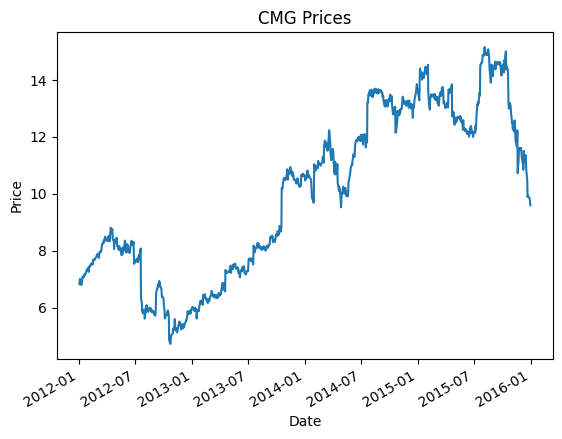

In [32]:
prices.plot();
plt.title(symbol + " Prices")
plt.ylabel("Price")
plt.xlabel("Date");


In [33]:
print("Mean:", prices.mean())
print("Standard Deviation:", prices.std())


Mean: 10.032733014753278
Standard Deviation: 2.9337747441407167


In [34]:
print("Summary Statistics")
prices.describe()


Summary Statistics


count    1006.000000
mean       10.032733
std         2.933775
min         4.724800
25%         7.431100
50%        10.425400
75%        12.936700
max        15.155400
Name: CMG, dtype: float64

In [35]:
modified_prices = prices * 2 - 10
modified_prices.head(5)


Date
2012-01-03    3.6508
2012-01-04    3.9500
2012-01-05    4.0192
2012-01-06    3.9580
2012-01-09    3.5896
Name: CMG, dtype: float64

In [36]:
noisy_prices = prices + 5 * pd.Series(np.random.normal(0, 5, len(prices)), index=prices.index) + 20
noisy_prices.head(5)


Date
2012-01-03     1.637868
2012-01-04    42.576673
2012-01-05    29.328655
2012-01-06    32.860003
2012-01-09    31.538983
dtype: float64

In [37]:
empty_series = prices + pd.Series(np.random.normal(0, 1, len(prices)))
empty_series.head(5)


Date
2012-01-03 00:00:00   NaN
2012-01-04 00:00:00   NaN
2012-01-05 00:00:00   NaN
2012-01-06 00:00:00   NaN
2012-01-09 00:00:00   NaN
dtype: float64

In [38]:
add_returns = prices.diff()[1:]
mult_returns = prices.pct_change()[1:]


Text(0, 0.5, 'Percent Returns')

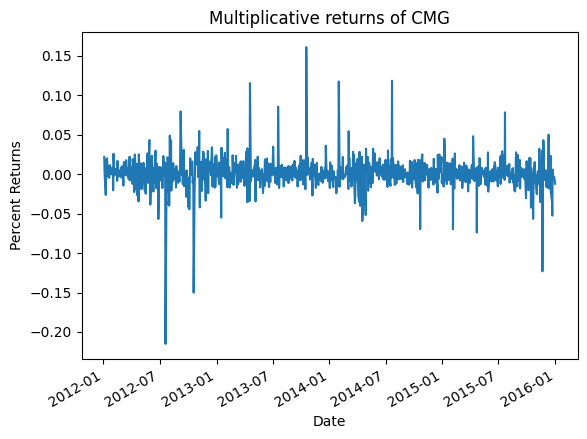

In [39]:
mult_returns.plot();
plt.title("Multiplicative returns of " + symbol)
plt.xlabel("Date")
plt.ylabel("Percent Returns")



In [40]:
rolling_mean = prices.rolling(30).mean()
rolling_mean.name = "30-day rolling mean"


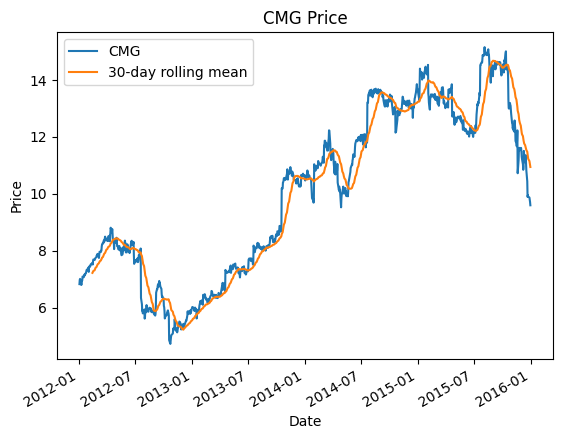

In [41]:
prices.plot()
rolling_mean.plot()
plt.title(symbol + " Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend();


In [42]:
rolling_std = prices.rolling(30).std()
rolling_std.name = "30-day rolling volatility"


Text(0, 0.5, 'Standard Deviation')

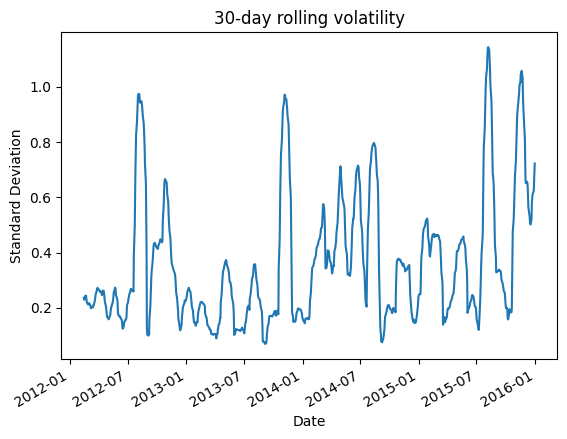

In [43]:
rolling_std.plot()
plt.title(rolling_std.name);
plt.xlabel("Date")
plt.ylabel("Standard Deviation")


In [44]:
print(np.median(mult_returns))


0.0002359792100385949


In [45]:
print(mult_returns.median())


0.0002359792100385949


#### Data Frames

In [46]:
dict_data = {
    'a' : [1, 2, 3, 4, 5],
    'b' : ['L', 'K', 'J', 'M', 'Z'],
    'c' : np.random.normal(0, 1, 5)
}

print(dict_data)


{'a': [1, 2, 3, 4, 5], 'b': ['L', 'K', 'J', 'M', 'Z'], 'c': array([ 1.30805032,  0.99928523,  0.79436299, -0.22306516,  0.27130509])}


In [47]:
frame_data = pd.DataFrame(dict_data, index=pd.date_range('2016-01-01', periods=5))
print(frame_data)


            a  b         c
2016-01-01  1  L  1.308050
2016-01-02  2  K  0.999285
2016-01-03  3  J  0.794363
2016-01-04  4  M -0.223065
2016-01-05  5  Z  0.271305


In [48]:
s_1 = pd.Series([2, 4, 6, 8, 10], name="Evens")
s_2 = pd.Series([1, 3, 5, 7, 9], name="Odds")
numbers = pd.concat([s_1, s_2], axis=1)
print(numbers)


   Evens  Odds
0      2     1
1      4     3
2      6     5
3      8     7
4     10     9


In [49]:
print(numbers.columns)


Index(['Evens', 'Odds'], dtype='str')


In [50]:
numbers.columns = ["Shmevens", "Shmodds"]
print(numbers)


   Shmevens  Shmodds
0         2        1
1         4        3
2         6        5
3         8        7
4        10        9


In [51]:
print(numbers.index)


RangeIndex(start=0, stop=5, step=1)


In [52]:
numbers.index = pd.date_range("2016-01-01", periods=len(numbers))
print(numbers)


            Shmevens  Shmodds
2016-01-01         2        1
2016-01-02         4        3
2016-01-03         6        5
2016-01-04         8        7
2016-01-05        10        9


In [53]:
numbers.values


array([[ 2,  1],
       [ 4,  3],
       [ 6,  5],
       [ 8,  7],
       [10,  9]])

In [54]:
type(numbers.values)


numpy.ndarray

In [67]:
symbol = ["CMG", "NVDA", "AAPL", "AMZN"]
start = "2012-01-01"
end="2016-01-01"

prices = yf.download(symbol, start=start, end=end)["Close"]


[*********************100%***********************]  4 of 4 completed


In [56]:
prices.CMG.head()


Date
2012-01-03    6.8254
2012-01-04    6.9750
2012-01-05    7.0096
2012-01-06    6.9790
2012-01-09    6.7948
Name: CMG, dtype: float64

In [58]:
prices.loc[:, "CMG"].head()


Date
2012-01-03    6.8254
2012-01-04    6.9750
2012-01-05    7.0096
2012-01-06    6.9790
2012-01-09    6.7948
Name: CMG, dtype: float64

In [59]:
print(type(prices.CMG))
print(type(prices.loc[:, "CMG"]))


<class 'pandas.Series'>
<class 'pandas.Series'>


In [62]:
prices.loc[:, ["CMG", "MCD"]].head()


Ticker,CMG,MCD
Date,,
2012-01-03,6.8254,67.553276
2012-01-04,6.9750,67.929176
2012-01-05,7.0096,68.229912
2012-01-06,6.9790,68.756149
2012-01-09,6.7948,68.100014


In [70]:
prices.loc["2015-12-15":"2015-12-22"]


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2015-12-15,24.865868,32.931999,11.0972,0.804180
2015-12-16,25.057159,33.788502,11.3566,0.809058
2015-12-17,24.526039,33.532501,11.0978,0.796862
2015-12-18,23.862135,33.207001,10.8216,0.783935
2015-12-21,24.154701,33.225498,10.4402,0.802472
2015-12-22,24.132202,33.157501,9.8922,0.803204


In [75]:
prices.loc["2015-12-15":"2015-12-22", ["AMZN", "NVDA"]]


Ticker,AMZN,NVDA
Date,,
2015-12-15,32.931999,0.804180
2015-12-16,33.788502,0.809058
2015-12-17,33.532501,0.796862
2015-12-18,33.207001,0.783935
2015-12-21,33.225498,0.802472
2015-12-22,33.157501,0.803204


In [74]:
prices.iloc[0:2, 1]


Date
2012-01-03    8.9515
2012-01-04    8.8755
Name: AMZN, dtype: float64

In [73]:
# Access prices with. integer index in
# [1, 3, 5, 7, 9, 11, 13, ..., 99]
# and in column - or 3
prices.iloc[list([1, 3, 5]) + list(range(7, 100, 2)), [0, 3]].head(20)


Ticker,AAPL,NVDA
Date,,
2012-01-04,12.376502,0.325459
2012-01-06,12.644722,0.333251
2012-01-10,12.669870,0.331876
2012-01-12,12.614488,0.323167
2012-01-17,12.713573,0.309873
2012-01-19,12.804877,0.328897
2012-01-23,12.794697,0.334856
2012-01-25,13.370956,0.340356
2012-01-27,13.389518,0.341731


In [76]:
prices.loc[prices.AMZN > prices.AAPL].head()


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2013-01-24,13.605669,13.6730,5.9924,0.281193
2013-01-25,13.284932,14.1995,6.0696,0.286268
2013-01-28,13.585432,13.8020,6.2338,0.290881
2013-03-01,13.076509,13.2870,6.3948,0.294986
2013-03-04,12.759978,13.6555,6.4352,0.293826


In [84]:
prices.loc[(prices.AMZN > prices.AAPL) & (~prices.NVDA.isna())].head()


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2013-01-24,13.605669,13.6730,5.9924,0.281193
2013-01-25,13.284932,14.1995,6.0696,0.286268
2013-01-28,13.585432,13.8020,6.2338,0.290881
2013-03-01,13.076509,13.2870,6.3948,0.294986
2013-03-04,12.759978,13.6555,6.4352,0.293826


In [88]:
s_1 = yf.download("TSLA", start=start, end=end)["Close"]
prices.loc[:, "TSLA"] = s_1
prices.head(5)


[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,AMZN,CMG,NVDA,TSLA
Date,,,,,
2012-01-03,12.310344,8.9515,6.8254,0.321791,1.872000
2012-01-04,12.376502,8.8755,6.9750,0.325459,1.847333
2012-01-05,12.513906,8.8805,7.0096,0.337147,1.808000
2012-01-06,12.644722,9.1305,6.9790,0.333251,1.794000
2012-01-09,12.624671,8.9280,6.7948,0.333251,1.816667


In [89]:
prices = prices.drop("TSLA", axis=1)
prices.head(5)


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2012-01-03,12.310344,8.9515,6.8254,0.321791
2012-01-04,12.376502,8.8755,6.9750,0.325459
2012-01-05,12.513906,8.8805,7.0096,0.337147
2012-01-06,12.644722,9.1305,6.9790,0.333251
2012-01-09,12.624671,8.9280,6.7948,0.333251


In [94]:
df_1 = yf.download(["SPY", "VOO"], start=start, end=end)["Close"]
df_2 = yf.download(["MSFT", "GOOGL", "SHAK"], start=start, end=end)["Close"]
df_3 = pd.concat([df_1, df_2], axis=1)
df_3.head()


[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  3 of 3 completed


Ticker,SPY,VOO,GOOGL,MSFT,SHAK
Date,,,,,
2012-01-03,99.312218,90.838722,16.515402,20.872486,NaN
2012-01-04,99.467995,90.994537,16.586637,21.363699,NaN
2012-01-05,99.732811,91.290573,16.356554,21.582018,NaN
2012-01-06,99.475769,91.103622,16.133423,21.917284,NaN
2012-01-09,99.717232,91.243851,15.449389,21.628790,NaN


In [95]:
filled0_prices = prices.fillna(0)
filled0_prices.head()


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2012-01-03,12.310344,8.9515,6.8254,0.321791
2012-01-04,12.376502,8.8755,6.9750,0.325459
2012-01-05,12.513906,8.8805,7.0096,0.337147
2012-01-06,12.644722,9.1305,6.9790,0.333251
2012-01-09,12.624671,8.9280,6.7948,0.333251


In [ ]:
bfilled_prices = prices.bfill()
bfilled_prices.head(5)


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2012-01-03,12.310344,8.9515,6.8254,0.321791
2012-01-04,12.376502,8.8755,6.9750,0.325459
2012-01-05,12.513906,8.8805,7.0096,0.337147
2012-01-06,12.644722,9.1305,6.9790,0.333251
2012-01-09,12.624671,8.9280,6.7948,0.333251


In [ ]:
# Best Choice for this scenario
dropped_prices = prices.dropna()
dropped_prices.head(5)


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2012-01-03,12.310344,8.9515,6.8254,0.321791
2012-01-04,12.376502,8.8755,6.9750,0.325459
2012-01-05,12.513906,8.8805,7.0096,0.337147
2012-01-06,12.644722,9.1305,6.9790,0.333251
2012-01-09,12.624671,8.9280,6.7948,0.333251


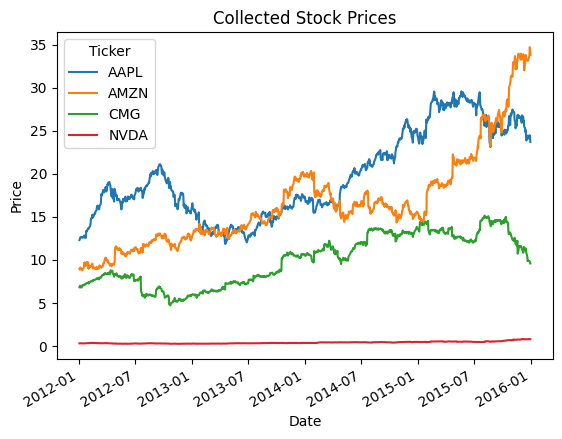

In [100]:
prices.plot()
plt.title("Collected Stock Prices")
plt.ylabel("Price")
plt.xlabel("Date");


In [ ]:
# axis = 0 refers to rows | axis = 1 refers to columns
prices.mean(axis=0)


Ticker
AAPL    19.704297
AMZN    16.623935
CMG     10.032733
NVDA     0.414266
dtype: float64

In [102]:
prices.std(axis=0)


Ticker
AAPL    5.055868
AMZN    5.614767
CMG     2.933775
NVDA    0.119814
dtype: float64

In [ ]:
prices.describe()


Ticker,AAPL,AMZN,CMG,NVDA
count,1006.000000,1006.000000,1006.000000,1006.000000
mean,19.704297,16.623935,10.032733,0.414266
std,5.055868,5.614767,2.933775,0.119814
min,11.863239,8.796500,4.724800,0.260825
25%,15.867344,12.895750,7.431100,0.321937
50%,18.200742,15.502000,10.425400,0.372086
75%,24.551478,18.757000,12.936700,0.480950
max,29.567261,34.698502,15.155400,0.823205


In [104]:
(2 * prices - 50).head(5)


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2012-01-03,-25.379313,-32.097000,-36.3492,-49.356417
2012-01-04,-25.246996,-32.249001,-36.0500,-49.349083
2012-01-05,-24.972189,-32.239000,-35.9808,-49.325705
2012-01-06,-24.710556,-31.739000,-36.0420,-49.333497
2012-01-09,-24.750658,-32.143999,-36.4104,-49.333497


In [106]:
mult_returns = prices.pct_change()[1:]
mult_returns.head()


Ticker,AAPL,AMZN,CMG,NVDA
Date,,,,
2012-01-04,0.005374,-0.008490,0.021918,0.011396
2012-01-05,0.011102,0.000563,0.004961,0.035915
2012-01-06,0.010454,0.028152,-0.004365,-0.011556
2012-01-09,-0.001586,-0.022178,-0.026394,0.000000
2012-01-10,0.003580,0.004368,0.004062,-0.004127


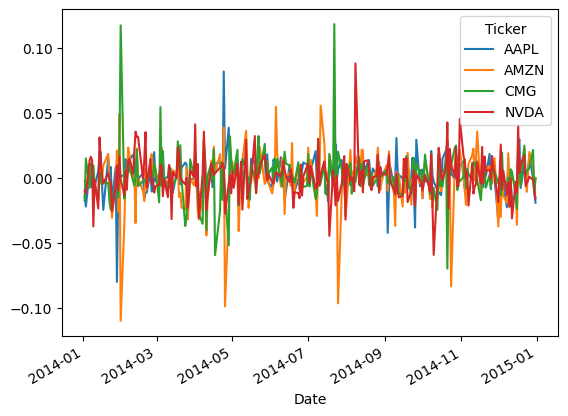

In [115]:
norm_returns = (mult_returns - mult_returns.mean(axis=0)/mult_returns.std(axis=0))
mult_returns.loc["2014-01-01":"2015-01-01"].plot();


In [116]:
rolling_mean = prices.rolling(window = 30).mean()
rolling_mean.columns = prices.columns


Text(0, 0.5, 'Price')

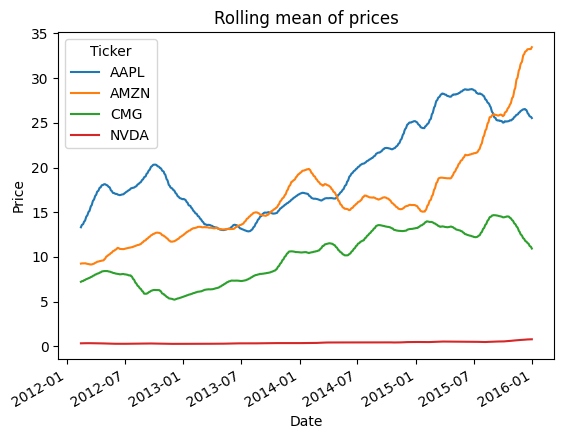

In [122]:
rolling_mean.plot()
plt.title("Rolling mean of prices")
plt.xlabel("Date")
plt.ylabel("Price")
# plt.legend();
